## Pythonの勉強（1）
- スタックフレーム
    * sys._getframe(1)が呼び出し元のフレーム
      f_code.co_filename
      f_lineno


In [1]:
import sys,inspect

print(f"current frame11 = {inspect.currentframe()}") 
def f1():
    print(f"current frame22 = {inspect.currentframe()}")     
    f2()

def f2():
    print(f"current frame33 = {inspect.currentframe()}")
    
    frame0 = sys._getframe(0) 
    frame1 = sys._getframe(1)
    frame2 = sys._getframe(2)
    frame3 = sys._getframe(3)
    frame4 = sys._getframe(4)    
    print(frame0)
    print(frame1)
    print(frame2)
    print(frame3)
    print(frame4)    
f1()
print(f"current frame44 = {inspect.currentframe()}")

current frame11 = <frame at 0x10970e350, file '/var/folders/0z/00_yqk5s1f98j4fv9f7rv3j40000gn/T/ipykernel_48193/1584236243.py', line 3, code <module>>
current frame22 = <frame at 0x10970e400, file '/var/folders/0z/00_yqk5s1f98j4fv9f7rv3j40000gn/T/ipykernel_48193/1584236243.py', line 5, code f1>
current frame33 = <frame at 0x1099d75a0, file '/var/folders/0z/00_yqk5s1f98j4fv9f7rv3j40000gn/T/ipykernel_48193/1584236243.py', line 9, code f2>
<frame at 0x1099d75a0, file '/var/folders/0z/00_yqk5s1f98j4fv9f7rv3j40000gn/T/ipykernel_48193/1584236243.py', line 16, code f2>
<frame at 0x10970e400, file '/var/folders/0z/00_yqk5s1f98j4fv9f7rv3j40000gn/T/ipykernel_48193/1584236243.py', line 6, code f1>
<frame at 0x109ab9b20, file '/var/folders/0z/00_yqk5s1f98j4fv9f7rv3j40000gn/T/ipykernel_48193/1584236243.py', line 21, code <module>>
<frame at 0x1099b6130, file '/Users/aratakekouji/.local/lib/python3.12/site-packages/IPython/core/interactiveshell.py', line 3577, code run_code>
<frame at 0x10969fe20, f

In [2]:
import sys

def debug(message):
    """現在行のファイル名と行番号を返す"""
    frame = sys._getframe(1)
    filename = frame.f_code.co_filename
    lineno   = frame.f_lineno
    del frame
    sys.stderr.write(f"** [DEBUG] {filename}:{lineno}: {message}\n")
    

## 使い方
debug("something wrong")

** [DEBUG] /var/folders/0z/00_yqk5s1f98j4fv9f7rv3j40000gn/T/ipykernel_48193/1908486899.py:13: something wrong


In [16]:
class Hello(object):
    def __call__(self,name):
        print(f"Hello, {name}")

hello = Hello()
hello("world")

Hello, world


In [3]:
class  deco:
    def __init__(self,func):
        self.func = func

    def hello(self,name):
        print(f'Hello, {name}')

    def __call__(self):
        print("start call func")
        self.func()
        print("end call func")
        return self
from functools import wraps

def hello2(name):
    print(f"Hello2, {name}")

def mdeco(name):
    def decof(func):
        @wraps(func)
        def wrapper(*args,**kyargs):
            print(f"start call func by {name}")
            print(wrapper.__name__)
            func(*args,**kyargs)
            print(f"end call func by {args[0]}")
            wrapper.hello2 = hello2
        return wrapper
    return decof
    
@mdeco("koji") 
def f(name):
    print(f"f func execution by {name}")

f("kyoko")
f.hello2("miki")

start call func by koji
f
f func execution by kyoko
end call func by kyoko
Hello2, miki


In [2]:
class Hello:
    def hello(self):
        print("Hello World")

class Test:
    def test(self):
        print("call test")

class Mixclass(Hello,Test):
    pass
    
x=Hello()
x.__class__ = Mixclass
print(dir(x))
x.hello()
x.test()

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'hello', 'test']
Hello World
call test


In [2]:
import types
class ConfigDSL:
    def __init__(self):
        self.config = {}

    def set(self, key, value):
        self.config[key] = value
    
    def __str__(self):
        return str(self.config)

# 動的にメソッドを追加する関数
def add_method(cls, method_name, method_func):
    setattr(cls, method_name, types.MethodType(method_func, cls))

# 新しいメソッドを追加
def enable_feature(self, feature_name):
    self.set(feature_name, True)

# DSLクラスにメソッドを追加
add_method(ConfigDSL, "enable_feature", enable_feature)

# DSLを使用
dsl = ConfigDSL()
dsl.enable_feature("dark_mode")
print(dsl)  # 出力: {'dark_mode': True}


TypeError: ConfigDSL.set() missing 1 required positional argument: 'value'

In [8]:
class ConfigDSL:
    def __init__(self):
        self.config = {}

    def set(self, key, value):
        self.config[key] = value
    
    def __str__(self):
        return str(self.config)

# 動的にメソッドを追加する関数
def add_method(cls, method_name, method_func):
    setattr(cls, method_name, method_func)

# 新しいメソッドを追加
def enable_feature(self, feature_name):
    self.set(feature_name, True)

# DSLクラスにメソッドを追加
add_method(ConfigDSL, "enable_feature", enable_feature)

# DSLを使用
dsl = ConfigDSL()
dsl.enable_feature("dark_mode")
print(dsl)  # 出力: {'dark_mode': True}


{'dark_mode': True}


In [6]:
class MyClass:
    def __init__(self, name):
        self.name = name

# 通常の関数を定義
def greet(self):
    return f"Hello, my name is {self.name}!"

# 関数を直接クラスに追加
MyClass.greet = greet

# インスタンスを作成してメソッドを呼び出し
obj = MyClass("Alice")
# 以下はエラーになります
print(obj.greet())  # TypeError: greet() missing 1 required positional argument: 'self'


Hello, my name is Alice!


In [12]:
class Mbase:
    pass
class Base(Mbase):
    pass
class Test1:
    pass
class Test(Base,Test1):
    pass

t=Test()
t.__class__.__bases__
t.__class__.__mro__

(__main__.Test, __main__.Base, __main__.Mbase, __main__.Test1, object)

In [12]:
def func():
    pass



def test(x):
    print("Hello test")

setattr(func,"test",test)
func.test(1)


Hello test


In [22]:
def test1():
    x = 1
    
    def test2():
        nonlocal x
        print(f"{x=}")
        x  += 1
        return x
    return test2

func = test1()
func()
func()
func()

x=1
x=2
x=3


4

In [15]:
def counter():
    count = 0

    def increment():
        nonlocal count
        count += 1
        return count

    return increment

counter_func = counter()

print(counter_func())  # 1
print(counter_func())  # 2
print(counter_func())  # 3


1
2
3


## Pythonの勉強（2）

1. メタクラスのメソッドは、クラスメソッドとなる。
2. 継承クラスのメソッドは、インスタンスメソッドとなる。

3. ううううううううううう
     

In [4]:
class Metaclass(type):
    def hello(self,name):
        print(f"Hello, {name}")
        
class Hello3:
    def hello3(self, name):
        print(f"Hello3, {name}")
        
class Hello(Hello3, metaclass=Metaclass):
    def hello2(self, name):
        print(f"Hello2, {name} !!!")

h=Hello.hello("koji")
h1=Hello().hello3("kyoko")

Hello, koji
Hello3, kyoko


In [5]:
python task管理のDSLの実例をプログラムで示して


SyntaxError: invalid syntax (3781749617.py, line 1)

In [1]:
class Task:
    def __init__(self, name, func):
        self.name = name
        self.func = func
        self.dependencies = []

    def depends_on(self, *tasks):
        self.dependencies.extend(tasks)
        return self

    def run(self):
        for task in self.dependencies:
            task.run()
        print(f"Running task: {self.name}")
        self.func()

class DSL:
    def __init__(self):
        self.tasks = {}

    def task(self, name):
        def decorator(func):
            self.tasks[name] = Task(name, func)
            return self.tasks[name]
        return decorator

    def run(self, task_name):
        task = self.tasks.get(task_name)
        if task:
            task.run()
        else:
            print(f"Task '{task_name}' not found.")

# DSLの使用例
dsl = DSL()

@dsl.task("task1")
def task1():
    print("Task 1 executed.")

@dsl.task("task2")
def task2():
    print("Task 2 executed.")

@dsl.task("task3")
def task3():
    print("Task 3 executed.")

dsl.tasks["task3"].depends_on(dsl.tasks["task1"], dsl.tasks["task2"])

dsl.run("task3")


Running task: task1
Task 1 executed.
Running task: task2
Task 2 executed.
Running task: task3
Task 3 executed.


In [2]:
from types import new_class

# exec_bodyとして使用する関数を定義
print(dir(new_class))
def class_body(custom_name):
    # クラスに属性を追加
    custom_name['greeting'] = "Hello"
    
    # クラスにメソッドを追加
    def greet(self):
        return self.greeting
    custom_name['greet'] = greet

# new_classを使ってクラスを動的に作成
MyClass = new_class('MyClass', (), {}, class_body)

# インスタンスを作成してメソッドを呼び出し
instance = MyClass()
print(instance.greet())  # "Hello"
print(instance.__class__.__qualname__)


['__annotations__', '__builtins__', '__call__', '__class__', '__closure__', '__code__', '__defaults__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__get__', '__getattribute__', '__getstate__', '__globals__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__kwdefaults__', '__le__', '__lt__', '__module__', '__name__', '__ne__', '__new__', '__qualname__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__type_params__']
Hello
MyClass


In [8]:
class A:
    def __init_subclass__(self):
        print(f"call __init_subclass__ {self}")
    def hello(self):
        print("Hello World")

class B(A):
    pass

c0=A().hello()
#c1=B().hello()

call __init_subclass__ <class '__main__.B'>
Hello World


In [7]:
from contextlib import contextmanager

class Test:
    def hello(self):
        print("Hello World")
    
@contextmanager
def with_block():
    print("Before block execution")
    # c1=Test()
    func = yield c1
    print("After block execution")

def my_block():
    print("This is inside the block")

# コンテキストマネージャを使って関数を渡す
with with_block() as f:
    print(dir(f))



Before block execution
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'hello']
After block execution


In [9]:
from contextlib import contextmanager

@contextmanager
def report(func,*args,**keyargs):
    print("start func")
    func(*args,**keyargs)
    yield 
    print("end func")

def f(*args,**keyargs):
    print(f"execute func {args[0]}")
    
with report(f,"ssss"):
    print("execute report")



start func
execute func ssss
execute report
end func


In [32]:
class Delegator():
    def __init__(self,dele):
        self.delegatee = dele

    def __getattr__(self,name):
        print(f"call {name} method")
        met=getattr(self.delegatee,name)
        return met
        

class Test(Delegator):
    def __init__(self,dele):
        super().__init__(dele)
        
    def test(self,name):
        print(f"self {name}")


class Delegatee:
    def hello(self):
        print("Hello world")
        print(f"self name = {self.__class__}")

    def print(self):
        print("print")

def test_func():
    d1 = Delegatee()
    t1 = Test(d1)
    t1.print()

test_func()


call print method
print


In [8]:
from pprint import pprint as pp
def test():
    pass

pp(test.__class__.__dict__)


mappingproxy({'__annotations__': <attribute '__annotations__' of 'function' objects>,
              '__builtins__': <member '__builtins__' of 'function' objects>,
              '__call__': <slot wrapper '__call__' of 'function' objects>,
              '__closure__': <member '__closure__' of 'function' objects>,
              '__code__': <attribute '__code__' of 'function' objects>,
              '__defaults__': <attribute '__defaults__' of 'function' objects>,
              '__dict__': <attribute '__dict__' of 'function' objects>,
              '__doc__': <member '__doc__' of 'function' objects>,
              '__get__': <slot wrapper '__get__' of 'function' objects>,
              '__globals__': <member '__globals__' of 'function' objects>,
              '__kwdefaults__': <attribute '__kwdefaults__' of 'function' objects>,
              '__module__': <member '__module__' of 'function' objects>,
              '__name__': <attribute '__name__' of 'function' objects>,
              '__ne

In [16]:
from types import MappingProxyType

dic = {'a': 1, 'b': 2}
dicp = MappingProxyType(dic)

dicp["a"] = 5
print(dicp["b"])

TypeError: 'mappingproxy' object does not support item assignment

In [7]:
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

def class_match(point):
    match point:
        case Point(x=0, y=0) :
            print("原点です")
        case Point(x=x, y=y) if x == y:
            print(f"xとyは等しい: ({x}, {y})")
        case Point(x=x, y=y):
            print(f"Point: ({x}, {y})")
        case _:
            print("デフォルトのケースです")

# 呼び出し例
p1 = Point(0, 0)
p2 = Point(3, 3)
p3 = Point(1, 2)

class_match(p1)  # 出力: 原点です
class_match(p2)  # 出力: xとyは等しい: (3, 3)
class_match(p3)  # 出力: Point: (1, 2)


原点です
xとyは等しい: (3, 3)
Point: (1, 2)


In [1]:
import re

text = "このテキストには電話番号が含まれています。03-1234-5678 や 090-1234-5678 です。"

# 電話番号の正規表現
phone_regex = r'\d{2,4}-\d{1,4}-\d{3,4}'

# マッチする電話番号を抽出
phone_numbers = re.findall(phone_regex, text)

print(phone_numbers)


['03-1234-5678', '090-1234-5678']


In [2]:
def f(x, a=[]):
    a.append(x) 
    print(a)

f(10)
f(20)
f(30)


[10]
[10, 20]
[10, 20, 30]


In [8]:
x = 0; y = 0
def f2(a, b, *, c=0):
    total = a + b + c
    total += x
    return total
print(dir(f2.__code__))
for k in dir(f2.__code__):
    if not k.startswith('__'):
        v = getattr(f2.__code__, k)
        print(f"{k}: {v}")

['__class__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '_co_code_adaptive', '_varname_from_oparg', 'co_argcount', 'co_cellvars', 'co_code', 'co_consts', 'co_exceptiontable', 'co_filename', 'co_firstlineno', 'co_flags', 'co_freevars', 'co_kwonlyargcount', 'co_lines', 'co_linetable', 'co_lnotab', 'co_name', 'co_names', 'co_nlocals', 'co_positions', 'co_posonlyargcount', 'co_qualname', 'co_stacksize', 'co_varnames', 'replace']
_co_code_adaptive: b'\x97\x00X\x00|\x01z\x00\x11\x00|\x02z\x00\x11\x00\x9a\x03|\x03t\x00\x11\x00\x00\x00\x00\x00\x00\x00z\r\x11\x00\x9a\x03|\x03S\x00'
_varname_from_oparg: <built-in method _varname_from_oparg of code object at 0x15a66d2f0>
co_argcount: 2
co_cellvars: ()
co_code: b'\x97\x00|\x00|\x01z\x00\x

/var/folders/0z/00_yqk5s1f98j4fv9f7rv3j40000gn/T/ipykernel_7140/2715369051.py:9: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
  v = getattr(f2.__code__, k)


In [11]:
"""
2021/02/14
@Yuya Shimizu

伝達関数モデル
"""
from control import tf, tfdata

##伝達関数を作成
#①式
Np = [0, 1]     #伝達関数の分子多項式の係数（0*s + 1）
Dp = [1, 2, 3]     #伝達関数の分母多項式の係数（1*s^2 + 2*s + 3）

P = tf(Np, Dp)

print(f"①式<伝達関数>\n{P}\n")


#②式
Np = [1, 2]     #伝達関数の分子多項式の係数（1*s + 2）
Dp = [1, 5, 3, 4]     #伝達関数の分母多項式の係数（1*s^3 + 5*s^2 + 3*s + 4）

P = tf(Np, Dp)

print(f"②式<伝達関数>\n{P}\n")


#③式
Np = [1, 3]     #伝達関数の分子多項式の係数（1*s + 3）
Dp = [1, 5, 8, 4]     #伝達関数の分母多項式の係数（(1*s + 1)(1*s + 2)^2  =  1*s^3 + 5*s^2 + 8*s + 4）


P = tf(Np, Dp)

print(f"③式<伝達関数>\n{P}\n")


#③式の別方法
Np1 = [1, 3]     #伝達関数の分子多項式の係数（1*s + 3）
Dp1 = [0, 1]     #伝達関数の分母多項式の係数（0*s + 1）
Np2 = [0, 1]     #伝達関数の分子多項式の係数（0*s + 1）
Dp2 = [1, 1]     #伝達関数の分母多項式の係数（1*s + 1）
Np3 = [0, 1]     #伝達関数の分子多項式の係数（0*s + 1）
Dp3 = [1, 2]     #伝達関数の分母多項式の係数（1*s + 2）

P1 = tf(Np1, Dp1)
P2 = tf(Np2, Dp2)
P3 = tf(Np3, Dp3)

P = P1 * P2 * P3**2

print(f"③式<伝達関数>（分割法）\n{P}\n")


##伝達関数の分子と分母の係数を抽出する
#シンプルに抽出する
numP = P.num
denP = P.den

print(f"<係数抽出>\n\n分子係数：{numP}, 分母係数：{denP}\n\n")


#入れ子を避ける抽出
[[numP]], [[denP]] = tfdata(P)
print(f"<係数抽出>（入れ子を避ける抽出）\n\n分子係数：{numP}, 分母係数：{denP}\n")


①式<伝達関数>
<TransferFunction>: sys[11]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


      1
-------------
s^2 + 2 s + 3


②式<伝達関数>
<TransferFunction>: sys[12]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


        s + 2
---------------------
s^3 + 5 s^2 + 3 s + 4


③式<伝達関数>
<TransferFunction>: sys[13]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


        s + 3
---------------------
s^3 + 5 s^2 + 8 s + 4


③式<伝達関数>（分割法）
<TransferFunction>: sys[21]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


        s + 3
---------------------
s^3 + 5 s^2 + 8 s + 4


<係数抽出>

分子係数：[[array([1, 3])]], 分母係数：[[array([1, 5, 8, 4])]]


<係数抽出>（入れ子を避ける抽出）

分子係数：[1 3], 分母係数：[1 5 8 4]



In [4]:
# カスタム例外クラスの定義
class CustomError(Exception):
    def __init__(self, message, code):
        self.message = message
        self.code = code
        super().__init__(self.message)

    def __str__(self):
        return f"Error Code {self.code}: {self.message}"
        
# カスタムエラーオブジェクトを発生させる関数
def raise_custom_error():
    raise CustomError("This is a custom error message", 404)

# メインプログラム
try:
    raise_custom_error()
except CustomError as e:
    print(f"Caught an error: {e}")


Caught an error: Error Code 404: This is a custom error message


In [5]:
class MyCustomValueError(ValueError):
    pass

try:
    raise MyCustomValueError("This is a custom value error!")
except MyCustomValueError as e:
    print(f"Caught: {e}")


Caught: This is a custom value error!


In [5]:
class CustomError(Exception):
    def __init__(self,message,code):
        self.message = message
        self.code = code
        super().__init__(message)

    def __str__(self):
        return f"error code: {self.code},error message: {self.message}"
    def __repr__(self):
        return f"error code2: {self.code},error message2: {self.message}"      
try:
    e1=CustomError("Cause Error",404)
    print(repr(e1))
    raise e1
except CustomError as e:
    print(e)


error code2: 404,error message2: Cause Error
error code: 404,error message: Cause Error


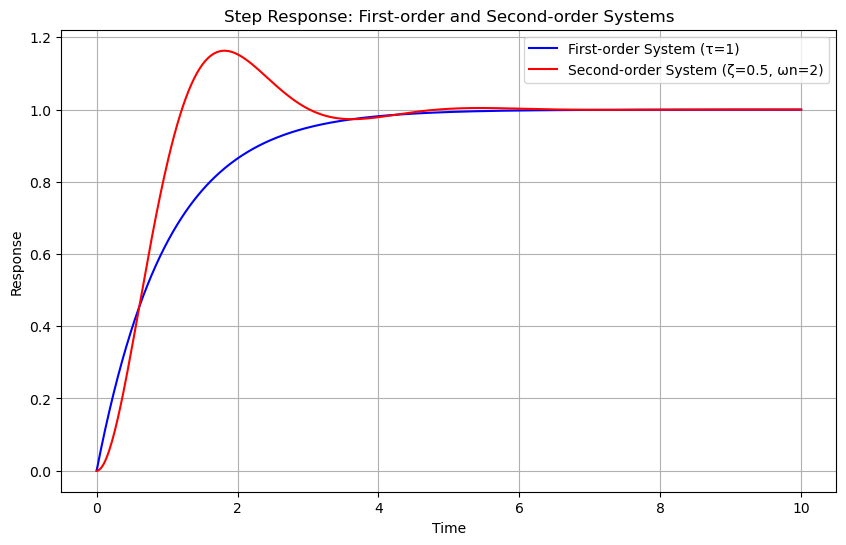

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Time array
t = np.linspace(0, 10, 500)

# First-order system: step response (H(s) = 1/(τs+1), τ = time constant)
tau1 = 1.0  # time constant for first-order system
first_order_response = 1 - np.exp(-t / tau1)

# Second-order system: step response (H(s) = 1/(ω²s² + 2ζωs + 1), ζ = damping ratio, ωn = natural frequency)
omega_n = 2.0  # natural frequency
zeta = 0.5     # damping ratio
second_order_response = 1 - (np.exp(-zeta * omega_n * t) * 
                            (np.cos(omega_n * np.sqrt(1 - zeta**2) * t) + 
                             zeta / np.sqrt(1 - zeta**2) * np.sin(omega_n * np.sqrt(1 - zeta**2) * t)))

# Plot the responses
plt.figure(figsize=(10, 6))
plt.plot(t, first_order_response, label='First-order System (τ=1)', color='b')
plt.plot(t, second_order_response, label='Second-order System (ζ=0.5, ωn=2)', color='r')

plt.title('Step Response: First-order and Second-order Systems')
plt.xlabel('Time')
plt.ylabel('Response')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Time array
x = np.linspace(-10, 10, 500)

# First-order system: step response (H(s) = 1/(τs+1), τ = time constant)
first_order_response = x**2

 #plt.figure(figsize=(10, 6))
plt.plot(t, first_order_response, label='First-order x**2 ', color='r')

plt.title('Step Response: First-order and Second-order Systems')
plt.xlabel('x')
plt.ylabel('x**2')
plt.grid(True)
plt.legend()
plt.show()


: 

In [8]:
def func(a,b,c,v=1,w=2,x=3):
    print("hello world")

func(1,2,3,1,x=3)


hello world


In [12]:
def func1(*args,**kwargs):
    print(args)
    print(kwargs)

func1(1,2,3,v=1,w=2,x=3)

(1, 2, 3)
{'v': 1, 'w': 2, 'x': 3}


In [15]:
def func2(a,*args,**kwargs):
    print(a)
    print(args)
    print(kwargs)
func2(1,2,3,4,v=3,w=4,x=5)

1
(2, 3, 4)
{'v': 3, 'w': 4, 'x': 5}
